In [1]:
using DifferentialEquations, Plots

In [2]:
# all constants
g_na = 120.0
g_k = 36.0
g_l = 0.3
c_m = 1.0
I_ext = 10.0
E_na = 50.0
E_k = -77.0
E_l = -54.4

-54.4

In [3]:
# rate funtions

# --- Potassium Gating (n) ---
alpha_n(V) = abs(V + 55.0) < 1e-6 ? 0.1 : 0.01 * (V + 55.0) / (1.0 - exp(-(V + 55.0) / 10.0))
beta_n(V) = 0.125 * exp(-(V + 65.0) / 80.0)


# --- Sodium Activation (m) ---
alpha_m(V) = abs(V + 40.0) < 1e-6 ? 1.0 : 0.1 * (V + 40.0) / (1.0 - exp(-(V + 40.0) / 10.0))
beta_m(V) = 4.0 * exp(-(V + 65.0) / 18.0)

# --- Sodium Inactivation (h) ---
alpha_h(V) = 0.07 * exp(-(V + 65.0) / 20.0)
beta_h(V) = 1.0 / (1.0 + exp(-(V + 35.0) / 10.0))

beta_h (generic function with 1 method)

## ode Hudgkin-huxley (HH)  model

In [4]:
function HH_model!(du, u_0, p, t)

    V, m, h, n = u_0
    g_na, g_k, g_l, c_m, I_ext, E_na, E_k, E_l = p




    du[1] = 1 / c_m * (I_ext - g_na * m^3 * h * (V - E_na) - g_k * n^4 * (V - E_k) - g_l * (V - E_l))
    du[2] = alpha_m(V) * (1 - m) - beta_m(V) * (m)
    du[3] = alpha_h(V) * (1 - h) - beta_h(V) * (h)
    du[4] = alpha_n(V) * (1 - n) - beta_n(V) * (n)
end

HH_model! (generic function with 1 method)

In [5]:
u_0 = [-65.0, 0.05, 0.6, 0.317]
tspan = (0.0, 30.0)
p = [g_na, g_k, g_l, c_m, I_ext, E_na, E_k, E_l]

8-element Vector{Float64}:
 120.0
  36.0
   0.3
   1.0
  10.0
  50.0
 -77.0
 -54.4

In [6]:
#defining the ode problem
prob = ODEProblem(HH_model!, u_0, tspan, p)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 30.0)
u0: 4-element Vector{Float64}:
 -65.0
   0.05
   0.6
   0.317

# solution of ode

In [7]:

sol = solve(prob, Rosenbrock23(), reltol=1e-6, abstol=1e-6,adaptive=false,dt = 0.01)


retcode: Success
Interpolation: specialized 2nd order "free" stiffness-aware interpolation
t: 3001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.060000000000000005
  0.07
  0.08
  0.09
  ⋮
 29.920000000001878
 29.93000000000188
 29.94000000000188
 29.950000000001882
 29.960000000001884
 29.970000000001885
 29.980000000001887
 29.99000000000189
 30.0
u: 3001-element Vector{Vector{Float64}}:
 [-65.0, 0.05, 0.6, 0.317]
 [-64.90176370515236, 0.05013373254136038, 0.5999934262245693, 0.3170026193139271]
 [-64.80409914389313, 0.05028671621059795, 0.5999828192583745, 0.3170079916478197]
 [-64.7069919766885, 0.050458102409716266, 0.5999681901605043, 0.31701610527878454]
 [-64.61042831275861, 0.05064709074492323, 0.5999495494839556, 0.3170269487498885]
 [-64.5143946645376, 0.05085292610827396, 0.5999269072900727, 0.3170405108629647]
 [-64.4188779065251, 0.05107489595902989, 0.5999002731612827, 0.3170567806724369]
 [-64.32386523803245, 0.05131232778984321, 0.59986965621227

In [8]:
println(length(sol[1, :]))
println(summary(sol[1, :]))

3001
3001-element Vector{Float64}


In [9]:
t = sol.t

3001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.060000000000000005
  0.07
  0.08
  0.09
  ⋮
 29.920000000001878
 29.93000000000188
 29.94000000000188
 29.950000000001882
 29.960000000001884
 29.970000000001885
 29.980000000001887
 29.99000000000189
 30.0

In [10]:
V=sol[1, :]
m = sol[2, :]
h= sol[3, :]
n=sol[4, :]
println(length(V))
println(length(m))
println(length(h))
println(length(n))


3001
3001
3001
3001


In [11]:
V

3001-element Vector{Float64}:
 -65.0
 -64.90176370515236
 -64.80409914389313
 -64.7069919766885
 -64.61042831275861
 -64.5143946645376
 -64.4188779065251
 -64.32386523803245
 -64.22934414938752
 -64.13530239121393
   ⋮
 -55.684206559592944
 -55.64882138450437
 -55.61310882459413
 -55.57706193880787
 -55.540673601783894
 -55.50393649779915
 -55.466843114478884
 -55.429385736258965
 -55.391556437597046

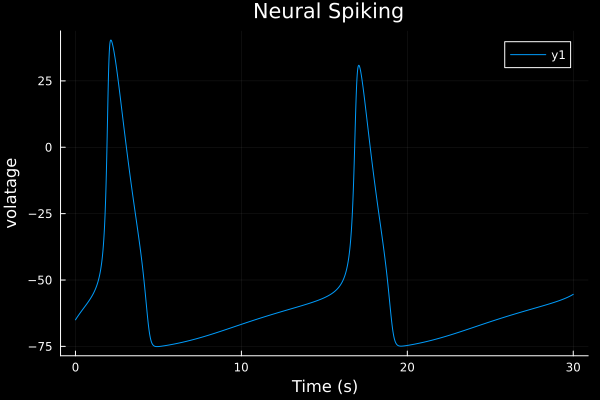

In [12]:
plot(title = " Neural Spiking" ,t,V,xlabel = "Time (s)",ylabel = "volatage",size(400,300),background_color=:black)

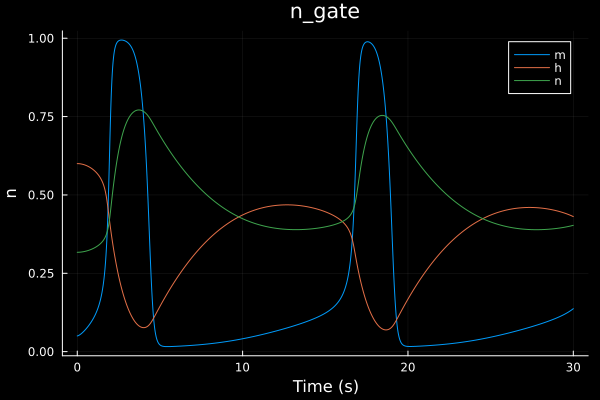

In [13]:
p = plot(title ="n_gate",  t,m,xlabel = "Time (s)",ylabel = "m",label = "m",background_color=:black)
plot!(t,h,xlabel = "Time (s)",ylabel = "h",label = "h")
plot!(t,n,xlabel = "Time (s)",ylabel = "n",label = "n")


In [14]:
using DataFrames

In [15]:
df = DataFrame( Time = t, V = V, m = m , h= h,n=n )

Row,Time,V,m,h,n
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.05,0.6,0.317
2,0.01,-64.9018,0.0501337,0.599993,0.317003
3,0.02,-64.8041,0.0502867,0.599983,0.317008
4,0.03,-64.707,0.0504581,0.599968,0.317016
5,0.04,-64.6104,0.0506471,0.59995,0.317027
6,0.05,-64.5144,0.0508529,0.599927,0.317041
7,0.06,-64.4189,0.0510749,0.5999,0.317057
8,0.07,-64.3239,0.0513123,0.59987,0.317076
9,0.08,-64.2293,0.0515646,0.599835,0.317097


In [16]:
using CSV

In [17]:
CSV.write("synthetic_data.csv",df)

"synthetic_data.csv"